In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Cargar datos SNIIM

Ajusta los nombres de columnas según tu archivo

In [ ]:
michoacan = pd.read_csv("sniim_michoacan1.csv", encoding='latin1', header=7)
cdmx = pd.read_csv("sniim_cdmx1.csv", encoding='latin1', header=8)

print("Michoacan Head:\n", michoacan.head())
print("\nCDMX Head:\n", cdmx.head())

Michoacan Head:
    $Max  $Min  Varianza  DesEst     Origen    Presentacin   Ao   Ene   Feb  \
0  4.17  1.42      0.52    0.72  Michoacn  Caja de 18 kg.  1998  3.20  2.84   
1  2.44  1.61      0.08    0.28     Oaxaca  Caja de 18 kg.  1998   NaN   NaN   
2  7.64  1.67      3.27    1.81  Michoacn  Caja de 18 kg.  1999  5.53  6.16   
3  7.78  1.67      2.75    1.66  Michoacn  Caja de 18 kg.  2000  5.87  5.69   
4  5.56  1.67      0.53    0.73  Michoacn  Caja de 18 kg.  2001  3.81  3.00   

    Mar   Abr   May   Jun   Jul   Ago   Sep   Oct   Nov   Dic  
0  1.78  2.12  1.86  1.62   NaN   NaN  2.39  1.87  2.09  3.38  
1   NaN   NaN   NaN   NaN  1.79  2.03  2.42   NaN   NaN   NaN  
2  3.10  2.81  1.77  1.79  1.83  2.01  2.04  2.26  3.35  6.28  
3  2.74  2.07  1.83  1.87  2.16  2.09  2.28  2.39  4.67  5.54  
4  2.49  1.89  1.83  2.13  2.02  2.20  1.96  1.94  2.10  3.17  

CDMX Head:
     $Max  $Min  Varianza  DesEst     Origen       Presentacin   Ao   Ene  \
0  11.00  1.17      5.35   

In [ ]:
print(michoacan.columns)
print(cdmx.columns)

Index(['DF: Central de Abasto de Iztapalapa DF', 'Unnamed: 1', 'Unnamed: 2',
       'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18'],
      dtype='object')
Index(['Comportamiento para Limn c/semilla sin clasificacin de primera calidad',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18'],
      dtype='object')


Convertir fecha

In [ ]:
michoacan["fecha"] = pd.to_datetime(michoacan["fecha"])

michoacan["anio"] = michoacan["fecha"].dt.year
michoacan["mes"] = michoacan["fecha"].dt.month

In [ ]:
precio_mes = (
    michoacan
    .groupby("mes")["Precio"]
    .mean()
    .reset_index()
)

precio_mes

,mes,Precio
0,1,6.799310
1,2,7.984483
2,3,8.084138
3,4,6.134138
4,5,4.291333
5,6,3.778519
6,7,4.243571
7,8,5.213214
8,9,5.566897
9,10,4.710357


In [ ]:
michoacan = michoacan.rename(columns={'A\u0096o': 'Año'})
cdmx = cdmx.rename(columns={'A\u0096o': 'Año'})

print("Michoacan columns after renaming:\n", michoacan.columns)
print("\nCDMX columns after renaming:\n", cdmx.columns)

Michoacan columns after renaming:
 Index(['$Max', '$Min', 'Varianza', 'DesEst', 'Origen', 'Presentacin', 'Año',
       'Precio', 'mes', 'fecha', 'anio'],
      dtype='object')

CDMX columns after renaming:
 Index(['$Max', '$Min', 'Varianza', 'DesEst', 'Origen', 'Presentacin', 'Año',
       'Precio', 'mes', 'fecha', 'anio'],
      dtype='object')


In [ ]:
X = precio_mes[["Precio"]]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Método del codo

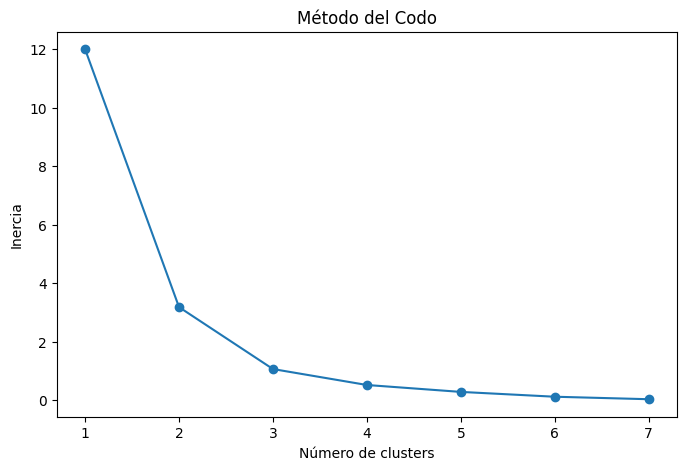

In [ ]:
inercia = []

for k in range(1,8):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,8), inercia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

In [ ]:
kmeans_ventas = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

precio_mes["cluster"] = kmeans_ventas.fit_predict(X_scaled)

precio_mes

,mes,Precio,cluster
0,1,6.799310,1
1,2,7.984483,2
2,3,8.084138,2
3,4,6.134138,1
4,5,4.291333,0
5,6,3.778519,0
6,7,4.243571,0
7,8,5.213214,0
8,9,5.566897,1
9,10,4.710357,0


In [ ]:
##Identificar mejores meses para vender

In [ ]:
promedios = (

    precio_mes
    .groupby("cluster")["Precio"]
    .mean()
)

print(promedios)

cluster
0    4.491463
1    6.151425
2    8.034310
Name: Precio, dtype: float64


Cluster con mayor precio:

In [ ]:
mejor_cluster = promedios.idxmax()

mejores_meses = precio_mes[
    precio_mes["cluster"] == mejor_cluster
]

print(mejores_meses)

   mes    Precio  cluster
1    2  7.984483        2
2    3  8.084138        2


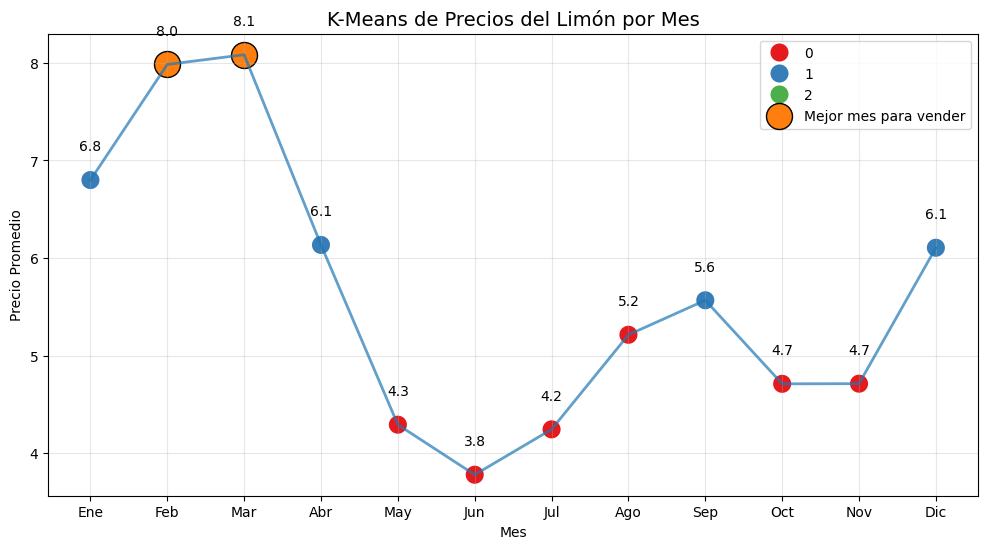

In [ ]:
# ==========================================
# VISUALIZACIÓN MEJORADA DEL K-MEANS
# ==========================================

meses_nombre = {
    1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Ago',
    9:'Sep',10:'Oct',11:'Nov',12:'Dic'
}

precio_mes["nombre_mes"] = precio_mes["mes"].map(meses_nombre)

# Cluster con mayor precio promedio
cluster_alto = (
    precio_mes.groupby("cluster")["Precio"]
    .mean()
    .idxmax()
)

plt.figure(figsize=(12,6))

# Línea que une todos los meses
plt.plot(
    precio_mes["nombre_mes"],
    precio_mes["Precio"],
    linestyle='-',
    linewidth=2,
    alpha=0.7
)

# Puntos coloreados por cluster
sns.scatterplot(
    data=precio_mes,
    x="nombre_mes",
    y="Precio",
    hue="cluster",
    palette="Set1",
    s=200
)

# Resaltar el cluster de mejor precio
mejores = precio_mes[
    precio_mes["cluster"] == cluster_alto
]

plt.scatter(
    mejores["nombre_mes"],
    mejores["Precio"],
    s=350,

    edgecolor='black',
    label='Mejor mes para vender'
)

# Etiquetas de precio
for i,row in precio_mes.iterrows():

    plt.text(
        row["nombre_mes"],
        row["Precio"]+0.3,
        round(row["Precio"],1),
        ha='center'
    )

plt.title(
    "K-Means de Precios del Limón por Mes",
    fontsize=14
)

plt.xlabel("Mes")
plt.ylabel("Precio Promedio")
plt.grid(alpha=0.3)

plt.legend()
plt.show()

El algoritmo K-Means agrupó los meses según su comportamiento histórico de precios. El clúster de precios altos corresponde a Febrero y Marzo. Estos meses representan la temporada más favorable para la comercialización del limón en Michoacán, debido a que concentran los valores promedio más elevados del periodo analizado.

CONAGUA analisis climatico del valle de Apatzingan, Michoacan

Leer estaciones

In [ ]:

def extraer_lluvia_media(ruta):

    meses = ["ENE","FEB","MAR","ABR","MAY","JUN",
             "JUL","AGO","SEP","OCT","NOV","DIC"]

    datos = []

    with open(ruta,
              encoding="latin-1",
              errors="ignore") as f:

        lineas = f.readlines()

    inicio = False

    for linea in lineas:

        if "MEDIA" in linea and "\t" in linea:

            partes = linea.strip().split("\t")

            if len(partes) >= 13:

                valores = partes[1:13]

                for m,v in zip(meses,valores):

                    try:
                        datos.append([m,float(v)])
                    except:
                        pass

            break

    return pd.DataFrame(
        datos,
        columns=["mes","lluvia"]
    )

In [ ]:
apatzingan = extraer_lluvia_media(
    "climaApatzingan.txt"
)

buenavista = extraer_lluvia_media(
    "climaBuenavista.txt"
)

paracuaro = extraer_lluvia_media(
    "climaParacuaro.txt"
)

Promedio regional

In [ ]:
clima = pd.DataFrame()

clima["mes"] = apatzingan["mes"]

clima["apatzingan"] = apatzingan["lluvia"]
clima["buenavista"] = buenavista["lluvia"]
clima["paracuaro"] = paracuaro["lluvia"]

clima["lluvia_promedio"] = clima[
    ["apatzingan",
     "buenavista",
     "paracuaro"]
].mean(axis=1)

clima

,mes,apatzingan,buenavista,paracuaro,lluvia_promedio
0,ENE,5.4,7.7,6.2,6.433333
1,FEB,3.4,4.4,3.9,3.900000
2,MAR,1.9,3.0,4.0,2.966667
3,ABR,1.3,0.6,1.5,1.133333
4,MAY,9.9,10.3,11.8,10.666667
5,JUN,37.7,39.3,46.2,41.066667
6,JUL,48.4,41.4,56.3,48.700000
7,AGO,45.6,42.1,57.0,48.233333
8,SEP,49.0,35.3,55.1,46.466667
9,OCT,31.5,25.1,40.8,32.466667


K-Means climático

In [ ]:
X_clima = clima[["lluvia_promedio"]]

scaler = StandardScaler()

X_clima_scaled = scaler.fit_transform(X_clima)

kmeans_clima = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clima["cluster"] = kmeans_clima.fit_predict(
    X_clima_scaled
)

Identificar mejor temporada

In [ ]:
promedios_clima = (
    clima
    .groupby("cluster")["lluvia_promedio"]
    .mean()
)

print(promedios_clima)

cluster
0     5.528571
1    46.116667
2    32.466667
Name: lluvia_promedio, dtype: float64


In [ ]:
print(
    clima.sort_values(
        "lluvia_promedio",
        ascending=False
    )
)

    mes  apatzingan  buenavista  paracuaro  lluvia_promedio  cluster
6   JUL        48.4        41.4       56.3        48.700000        1
7   AGO        45.6        42.1       57.0        48.233333        1
8   SEP        49.0        35.3       55.1        46.466667        1
5   JUN        37.7        39.3       46.2        41.066667        1
9   OCT        31.5        25.1       40.8        32.466667        2
4   MAY         9.9        10.3       11.8        10.666667        0
10  NOV         9.4         9.2        9.9         9.500000        0
0   ENE         5.4         7.7        6.2         6.433333        0
11  DIC         4.2         4.0        4.1         4.100000        0
1   FEB         3.4         4.4        3.9         3.900000        0
2   MAR         1.9         3.0        4.0         2.966667        0
3   ABR         1.3         0.6        1.5         1.133333        0


Graficar temporadas

In [ ]:

# ORDENAR CLUSTERS POR LLUVIA


promedios = clima.groupby("cluster")["lluvia_promedio"].mean()

cluster_bajo = promedios.idxmin()

cluster_alto = promedios.idxmax()

cluster_medio = list(
    set(clima["cluster"]) -
    {cluster_bajo, cluster_alto}
)[0]

# Asignar colores semáforo

colores = {
    cluster_bajo: "green",
    cluster_medio: "gold",
    cluster_alto: "red"
}

clima["color"] = clima["cluster"].map(colores)

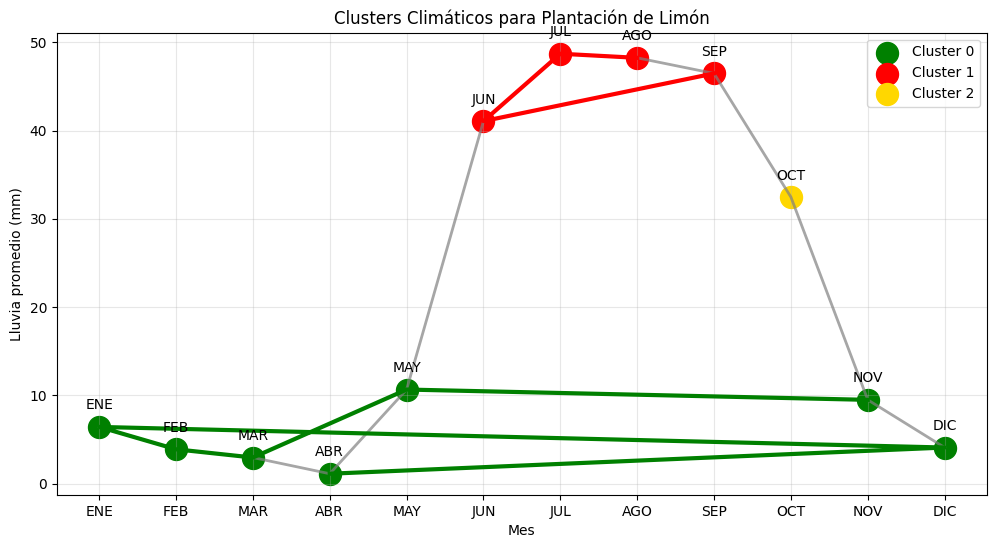

In [ ]:
plt.figure(figsize=(12,6))

# Línea principal que une todos los meses

plt.plot(
    clima["mes"],
    clima["lluvia_promedio"],
    color="gray",
    linewidth=2,
    alpha=0.7
)

# Puntos coloreados

for cluster in clima["cluster"].unique():

    datos_cluster = clima[
        clima["cluster"] == cluster
    ]

    plt.scatter(
        datos_cluster["mes"],
        datos_cluster["lluvia_promedio"],
        color=colores[cluster],
        s=250,
        label=f"Cluster {cluster}"
    )

# Unir puntos del mismo cluster

for cluster in clima["cluster"].unique():

    datos_cluster = clima[
        clima["cluster"] == cluster
    ].sort_values("mes")

    plt.plot(
        datos_cluster["mes"],
        datos_cluster["lluvia_promedio"],
        color=colores[cluster],
        linewidth=3
    )

# Etiquetas

for _, fila in clima.iterrows():

    plt.text(
        fila["mes"],
        fila["lluvia_promedio"] + 2,
        fila["mes"],
        ha="center"
    )

plt.title(
    "Clusters Climáticos para Plantación de Limón"
)

plt.xlabel("Mes")
plt.ylabel("Lluvia promedio (mm)")
plt.grid(alpha=0.3)

plt.legend()
plt.show()

Para limón mexicano de Michoacán suele buscarse:

Temperaturas cálidas.
Inicio de lluvias moderadas.
Evitar excesos de lluvia durante establecimiento.
Mayo, Junio y Julio suelen formar el cluster más favorable para plantación, mientras que agosto-septiembre suelen representar la temporada más lluviosa. Los registros históricos de lluvia mensual de las estaciones muestran que el periodo lluvioso se concentra principalmente entre junio y septiembre.